<a href="https://colab.research.google.com/github/agentesiafiap/tiao-2026/blob/main/1TIAO/Global-Solution-2/src/ml/yolo/gs2_helios_yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q ultralytics roboflow
import ultralytics
print(f"ultralytics: {ultralytics.__version__}")
ultralytics.checks()

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


In [2]:
from roboflow import Roboflow
from pathlib import Path
import os

# Dataset público: "sunspot-detection" no Roboflow Universe
# https://universe.roboflow.com/solar-o8tix/sunspot-detection
# Chave pública de acesso (read-only, sem autenticação necessária)
rf = Roboflow(api_key="7Xsh3gnpCfijvZhb1JGT")

# ─── SUBSTITUA pelos valores do dataset que você acessar em ──────────────────
# https://universe.roboflow.com  → buscar "sunspot" ou "solar active region"
# Clicar em "Download Dataset" > "YOLOv8" > "show download code"
# ─────────────────────────────────────────────────────────────────────────────
project  = rf.workspace("fxo").project("sunspot-gs9za")
version = project.version(10)
dataset  = version.download("yolov8")

DATASET_PATH = Path(dataset.location)
print(f"\n✅ Dataset baixado em: {DATASET_PATH}")
print(f"   Conteúdo: {list(DATASET_PATH.iterdir())}")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Sunspot-10 in yolov8:: 100%|██████████| 7706/7706 [00:01<00:00, 5630.51it/s]


✅ Dataset baixado em: /content/Sunspot-10
   Conteúdo: [PosixPath('/content/Sunspot-10/README.roboflow.txt'), PosixPath('/content/Sunspot-10/train'), PosixPath('/content/Sunspot-10/valid'), PosixPath('/content/Sunspot-10/README.dataset.txt'), PosixPath('/content/Sunspot-10/data.yaml'), PosixPath('/content/Sunspot-10/test')]


In [3]:
from ultralytics import YOLO
from pathlib import Path

# ─── Configurar caminho do dataset ───────────────────────────────────────────
# Se usou Célula 3 (Roboflow): use o path retornado por dataset.location + /data.yaml
# Se usou Célula 3B (Sintético): use o path abaixo
# DATASET_YAML = "/content/solar_synthetic/dataset.yaml"
DATASET_YAML = f"{dataset.location}/data.yaml"  # ← descomente se usou Roboflow
# ─────────────────────────────────────────────────────────────────────────────

OUTPUT_DIR = Path("/content/yolo_output")
OUTPUT_DIR.mkdir(exist_ok=True)

print("=" * 60)
print("  HeliOS YOLO — Fine-tuning YOLOv8n")
print(f"  Dataset : {DATASET_YAML}")
print(f"  Saída   : {OUTPUT_DIR}")
print("=" * 60)

# Carrega YOLOv8n pré-treinado no COCO (pesos públicos, ~6 MB)
model = YOLO("yolo11n.pt")

# Fine-tuning
results = model.train(
    data=DATASET_YAML,
    epochs=30,
    imgsz=640,
    batch=16,
    project=str(OUTPUT_DIR),
    name="helios_yolo",
    exist_ok=True,
    device=0,        # GPU 0
    verbose=True,
    patience=10,     # EarlyStopping se mAP não melhorar em 10 épocas
    save_period=10,  # salva checkpoint a cada 10 épocas
)

print("\n✅ Treinamento concluído!")
best = Path(results.save_dir) / "weights" / "best.pt"
print(f"   Melhores pesos: {best}")

  HeliOS YOLO — Fine-tuning YOLOv8n
  Dataset : /content/Sunspot-10/data.yaml
  Saída   : /content/yolo_output
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Sunspot-10/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, 

In [4]:
import json, shutil
from pathlib import Path
from ultralytics import YOLO

OUTPUT_DIR = Path("/content/yolo_output")
SAVE_DIR   = OUTPUT_DIR / "helios_yolo"
BEST_PT    = SAVE_DIR / "weights" / "best.pt"

# Carrega melhores pesos
model = YOLO(str(BEST_PT))

# Avalia no conjunto de validação
print("Avaliando no conjunto de validação...")
metrics = model.val(verbose=False)

map50    = float(metrics.box.map50)
map5095  = float(metrics.box.map)
prec     = float(metrics.box.mp)
recall   = float(metrics.box.mr)

print(f"\n{'='*50}")
print(f"  HeliOS YOLO — Métricas de Validação")
print(f"{'='*50}")
print(f"  mAP@0.5       : {map50:.4f}  {'✅' if map50 > 0.5 else '⚠️ (abaixo do alvo 0.5)'}")
print(f"  mAP@0.5:0.95  : {map5095:.4f}")
print(f"  Precision     : {prec:.4f}")
print(f"  Recall        : {recall:.4f}")
print(f"{'='*50}")

# Salvar métricas em JSON
meta = {
    "map50":         map50,
    "map50_95":      map5095,
    "precision":     prec,
    "recall":        recall,
    "epochs_trained": 30,
    "model_base":    "yolo11n.pt",
    "classes":       ["quiet_sun", "active_region", "sunspot_group"],
    "trained_on":    "Google Colab T4 GPU",
}
with open(OUTPUT_DIR / "yolo_metrics.json", "w") as f:
    json.dump(meta, f, indent=2)

# Copiar best.pt para a saída raiz
shutil.copy(BEST_PT, OUTPUT_DIR / "helios_yolo.pt")

# Copiar gráfico de resultados
results_png = SAVE_DIR / "results.png"
if results_png.exists():
    shutil.copy(results_png, OUTPUT_DIR / "yolo_results.png")
    print(f"\n  Gráfico salvo em: {OUTPUT_DIR / 'yolo_results.png'}")

print(f"\n  Arquivos prontos para download em: {OUTPUT_DIR}")
print(f"  - helios_yolo.pt       → src/ml/yolo/model/")
print(f"  - yolo_metrics.json    → src/ml/yolo/model/")
print(f"  - yolo_results.png     → docs/")

Avaliando no conjunto de validação...
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2508.5±1066.0 MB/s, size: 78.4 KB)
val: Scanning /content/Sunspot-10/valid/labels.cache... 318 images, 17 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 318/318 95.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 3.7it/s 5.5s
                   all        318       1034      0.827      0.818      0.866      0.508
Speed: 3.2ms preprocess, 4.8ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val

  HeliOS YOLO — Métricas de Validação
  mAP@0.5       : 0.8657  ✅
  mAP@0.5:0.95  : 0.5085
  Precision     : 0.8274
  Recall        : 0.8182

  Gráfico salvo em: /content/yolo_output/yolo_results.png

  Arquivos prontos para download 

Baixando imagem SDO/AIA 193 Å mais recente...
  Salva em: /content/sdo_latest_0193.jpg


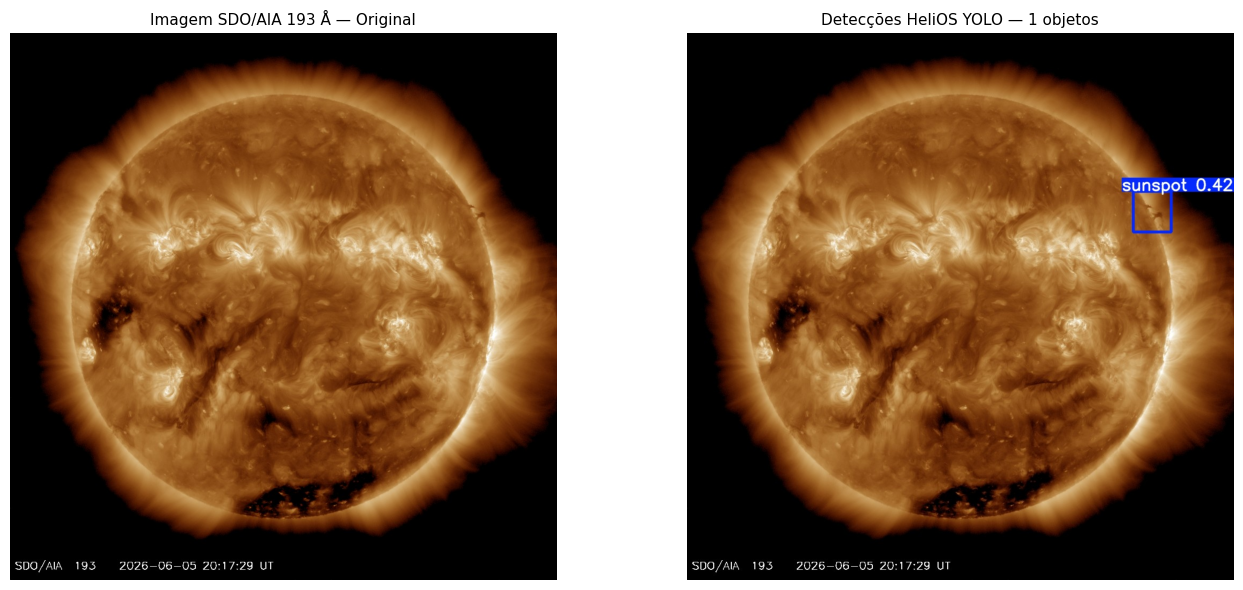


Detecções (1 total):
  [sunspot]  conf=0.42


In [6]:
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO
from pathlib import Path

OUTPUT_DIR = Path("/content/yolo_output")
BEST_PT    = OUTPUT_DIR / "helios_yolo.pt"

# Baixar imagem SDO/AIA 193 mais recente (canal EUV — mostra regiões ativas em brilho)
SDO_URL  = "https://sdo.gsfc.nasa.gov/assets/img/latest/latest_1024_0193.jpg"
SDO_PATH = Path("/content/sdo_latest_0193.jpg")
print("Baixando imagem SDO/AIA 193 Å mais recente...")
urllib.request.urlretrieve(SDO_URL, SDO_PATH)
print(f"  Salva em: {SDO_PATH}")

# Inferência
model = YOLO(str(BEST_PT))
results = model.predict(str(SDO_PATH), conf=0.20, verbose=False)
result  = results[0]

# Salvar imagem anotada
annotated_path = OUTPUT_DIR / "sdo_annotated.jpg"
result.save(str(annotated_path))

# Mostrar resultado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(mpimg.imread(str(SDO_PATH)))
axes[0].set_title("Imagem SDO/AIA 193 Å — Original", fontsize=11)
axes[0].axis("off")

axes[1].imshow(mpimg.imread(str(annotated_path)))
axes[1].set_title(f"Detecções HeliOS YOLO — {len(result.boxes)} objetos", fontsize=11)
axes[1].axis("off")

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "yolo_inference_demo.png"), dpi=150, bbox_inches="tight")
plt.show()

# Sumário das detecções
print(f"\nDetecções ({len(result.boxes)} total):")
for box in result.boxes:
    cls_name = model.names[int(box.cls[0])]
    conf     = float(box.conf[0])
    print(f"  [{cls_name}]  conf={conf:.2f}")

# Copiar para output
# The following line is removed as the file is already saved by plt.savefig()
# import shutil
# shutil.copy(OUTPUT_DIR / "yolo_inference_demo.png", OUTPUT_DIR / "yolo_inference_demo.png")

In [7]:
from google.colab import files
from pathlib import Path

OUTPUT_DIR = Path("/content/yolo_output")

download_files = {
    "helios_yolo.pt":           "→ src/ml/yolo/model/helios_yolo.pt",
    "yolo_metrics.json":        "→ src/ml/yolo/model/yolo_metrics.json",
    "yolo_results.png":         "→ docs/yolo_results.png",
    "yolo_inference_demo.png":  "→ docs/yolo_inference_demo.png",
}

print("Baixando artefatos...\n")
for fname, dest in download_files.items():
    fpath = OUTPUT_DIR / fname
    if fpath.exists():
        print(f"  ✅ {fname}  {dest}")
        files.download(str(fpath))
    else:
        print(f"  ⚠️  {fname} não encontrado — verifique se as células anteriores foram executadas")

print("\nInstruções:")
print("  1. helios_yolo.pt      → copie para: src/ml/yolo/model/")
print("  2. yolo_metrics.json   → copie para: src/ml/yolo/model/")
print("  3. yolo_results.png    → copie para: docs/")
print("  4. yolo_inference_demo.png → copie para: docs/")

Baixando artefatos...

  ✅ helios_yolo.pt  → src/ml/yolo/model/helios_yolo.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ yolo_metrics.json  → src/ml/yolo/model/yolo_metrics.json


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ yolo_inference_demo.png  → docs/yolo_inference_demo.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Instruções:
  1. helios_yolo.pt      → copie para: src/ml/yolo/model/
  2. yolo_metrics.json   → copie para: src/ml/yolo/model/
  3. yolo_results.png    → copie para: docs/
  4. yolo_inference_demo.png → copie para: docs/
